<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/DL/ANN/%EB%8B%A4%EC%B8%B5_%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0%EC%9C%BC%EB%A1%9C_%EC%86%90%EA%B8%80%EC%94%A8_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다층 퍼셉트론으로 손글씨 분류하기

## 숫자 필기 데이터 소개

- 사이킷런 패키지에서 제공하는 분류용 예제 데이터
- 0 부터 9까지의 숫자를 손으로 쓴 이미지 데이터
- 각 이미지는 0부터 15까지 8x8=64 픽셀 해상도의 흑백 이미지
- 해당 이미지가 1,797개 있음

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [3]:
digits = load_digits() # 이미지 데이터 로드

In [4]:
print(digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [5]:
print('전체 샘플의 수: {}'. format(len(digits.images)))

전체 샘플의 수: 1797


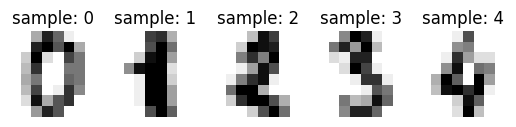

In [6]:
# 상위 5개 샘플만 시각화
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:5]):
  plt.subplot(2, 5, index + 1)
  plt.axis('off')
  plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
  plt.title('sample: %i' % label)

In [7]:
for i in range(5):
  print(i, '번 인덱스 샘플의 레이블: ', digits.target[i])

0 번 인덱스 샘플의 레이블:  0
1 번 인덱스 샘플의 레이블:  1
2 번 인덱스 샘플의 레이블:  2
3 번 인덱스 샘플의 레이블:  3
4 번 인덱스 샘플의 레이블:  4


- `digits.images`는 모든 샘플을 8x8 행렬로 저장하고 있음
- 더 나은 방법은 `digits.data`를 사용하는 것 -> 이는 8x8 행렬을 전부 64차원의 벡터로 변환해서 저장한 상태

In [8]:
print(digits.data[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [9]:
X = digits.data # 이미지 (특성 행렬)
Y = digits.target # 각 이미지 특성에 대한 레이블

## 다층 퍼셉트론 분류기 만들기

In [10]:
import torch
import torch.nn as nn
from torch import optim

Pytorch를 사용하여 다층 퍼셉트론 모델을 정의하기
- `nn.Seqential`을 사용하여 모델의 레이어들을 순차적으로 쌓아올리는 구조로 구현

1. 1st layer (`nn.Linear(64, 32)`): 입력층, 입력 데이터의 특성 수가 64개인 경우를 가정함. -> 첫 번째 은닉층 역할을 함.
2. 1st activation-function (`nn.ReLU()`): 첫 번째 은닉층의 출력을 비선형적으로 변환하기 위해 적용
---
1. 2nd layer (`nn.Linear(32, 16)`)
2. 2nd activation (`nn.ReLU()`)
---
1. 3rd layer (`nn.Linear(16, 10)`): 세 번째 은닉층이자 출력층, 이전 레이어의 출력 16개를 받아 최종적으로 10개의 클래스로 출력함.

In [11]:
# 모델 정의
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

In [12]:
# 입력 데이터와 레이블을 텐서로 변환
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.int64)

In [13]:
# 비용 함수
loss_fn = nn.CrossEntropyLoss() # 소프트맥스 함수 포함

In [14]:
optimizer = optim.Adam(model.parameters())

In [15]:
losses = []

In [17]:
# 총 100번의 에포크 동안 모델 학습
for epoch in range(100):
  optimizer.zero_grad()
  y_pred = model(X)
  loss = loss_fn(y_pred, Y)
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print('Epoch {:4d}/{} Cost {:.6f}'.format(
        epoch, 100, loss.item()
    ))

  # 손실 값을 리스트에 추가하여 추적
  losses.append(loss.item())

Epoch    0/100 Cost 2.362478
Epoch   10/100 Cost 2.093030
Epoch   20/100 Cost 1.775821
Epoch   30/100 Cost 1.421880
Epoch   40/100 Cost 1.067156
Epoch   50/100 Cost 0.744567
Epoch   60/100 Cost 0.514948
Epoch   70/100 Cost 0.364353
Epoch   80/100 Cost 0.271681
Epoch   90/100 Cost 0.214136


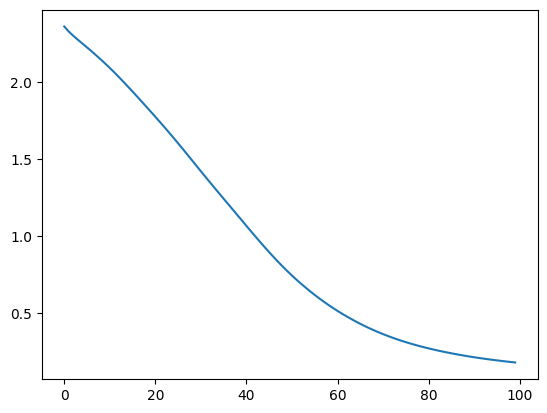

In [18]:
plt.plot(losses)

- 에포크 수가 늘어남에 따라 loss 가 줄어드는 것을 확인할 수 있음